# RAG Diagnostics Report - Worked Example

This notebook demonstrates the final report structure using synthetic offline outputs for a RAG system. It compares retrieval strategies and shows how to interpret the results without calling the API.

## Purpose
Use this notebook as the gold standard example for the final RAG diagnostics report once real exported datasets are available.

## Data contract and assumptions

The example below mimics the offline datasets produced from the RAG evaluation workflow. It keeps the same analysis structure you will use with real exported files, but all rows are synthetic.

### Checklist
- [x] The notebook uses DeepEval-style output columns.
- [x] The example includes three RAG strategies.
- [x] The example includes Expert and Operational scenarios.
- [x] The notebook includes a latency column for trade-off analysis.

## Endpoint schema and execution metadata

The worked example is aligned with the offline export shape. The execution metadata makes it possible to compare retrieval strategy, HyDE usage, and latency in a single report.

### Expected fields
- `Question`
- `Actual Answer`
- `Expected Output`
- `retrieval_context`
- `search_type`
- `search_method`
- `use_hyde`
- `model_name`
- `latency_s`
- `* Score` metric columns
- `* Reason` metric columns

### Checklist
- [x] The example matches the offline export contract.
- [x] Retrieval strategy is visible in every run.
- [x] Metric reasons are available for qualitative review.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

ENDPOINT_CORE_COLUMNS = [
    'Question',
    'Actual Answer',
    'Expected Output',
]

METRIC_SCORE_COLUMNS = [
    'Correctness Score',
    'Faithfulness Score',
    'Answer Relevancy Score',
    'ContextualPrecision Score',
    'ContextualRecall Score',
    'ContextualRelevancy Score',
]

METRIC_REASON_COLUMNS = [
    'Correctness Reason',
    'Faithfulness Reason',
    'Answer Relevancy Reason',
    'ContextualPrecision Reason',
    'ContextualRecall Reason',
    'ContextualRelevancy Reason',
]


def normalize_endpoint_export(df):
    if df.empty:
        return df
    rename_map = {
        'question': 'Question',
        'query': 'Question',
        'actual_answer': 'Actual Answer',
        'answer': 'Actual Answer',
        'result': 'Actual Answer',
        'expected_output': 'Expected Output',
        'reference': 'Expected Output',
        'latency': 'latency_s',
    }
    return df.rename(columns={source: target for source, target in rename_map.items() if source in df.columns})


def validate_endpoint_export(df):
    required_columns = ENDPOINT_CORE_COLUMNS + METRIC_SCORE_COLUMNS
    missing_columns = [column for column in required_columns if column not in df.columns]
    return {
        'valid': not missing_columns,
        'missing': missing_columns,
    }


def detect_metric_columns(df):
    return [column for column in df.columns if column.endswith(' Score')] if not df.empty else []


def build_summary_table(df):
    metric_columns = detect_metric_columns(df)
    if df.empty or not metric_columns:
        return pd.DataFrame()
    group_columns = ['run_name', 'system_type', 'scenario', 'search_type', 'search_method', 'use_hyde', 'model_name']
    numeric_columns = metric_columns + (['latency_s'] if 'latency_s' in df.columns else [])
    return df.groupby(group_columns, as_index=False)[numeric_columns].mean()


def build_wins_table(summary_df, metric_columns):
    if summary_df.empty or not metric_columns:
        return pd.DataFrame()
    rows = []
    for scenario_name in summary_df['scenario'].dropna().unique():
        subset = summary_df[summary_df['scenario'] == scenario_name]
        for metric in metric_columns:
            best_row = subset.loc[subset[metric].idxmax()]
            rows.append({
                'scenario': scenario_name,
                'metric': metric,
                'winner': best_row['run_name'],
                'score': best_row[metric],
            })
    return pd.DataFrame(rows)


def build_reason_table(df, max_rows=8):
    reason_columns = [column for column in df.columns if column.endswith(' Reason')]
    if df.empty or not reason_columns:
        return pd.DataFrame()
    preview_columns = ['run_name', 'system_type', 'scenario', 'search_method', 'use_hyde', 'Question'] + reason_columns
    preview_columns = [column for column in preview_columns if column in df.columns]
    return df[preview_columns].head(max_rows)


def plot_metric_bars(summary_df, metric_columns):
    if summary_df.empty or not metric_columns:
        print('No data available for metric bars yet.')
        return
    melted = summary_df.melt(id_vars=['run_name', 'system_type', 'scenario'], value_vars=metric_columns, var_name='metric', value_name='score')
    g = sns.catplot(
        data=melted,
        kind='bar',
        x='metric',
        y='score',
        hue='run_name',
        col='scenario',
        palette='Set2',
        height=4.5,
        aspect=1.4,
        sharey=True,
    )
    g.set_xticklabels(rotation=45, ha='right')
    g.set_titles('{col_name}')
    g.figure.suptitle('RAG metric comparison by strategy and scenario', y=1.05)
    plt.show()


def plot_metric_distributions(df, metric_columns):
    if df.empty or not metric_columns:
        print('No data available for distribution plots yet.')
        return
    melted = df.melt(id_vars=['run_name', 'system_type', 'scenario'], value_vars=metric_columns, var_name='metric', value_name='score')
    _, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=melted, x='metric', y='score', hue='run_name', ax=ax, palette='Set3')
    ax.set_title('Score dispersion by metric')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


def plot_latency_scatter(df):
    if df.empty or 'latency_s' not in df.columns:
        print('Latency is not available in the current dataset.')
        return
    quality_columns = [column for column in detect_metric_columns(df) if column != 'latency_s']
    df_plot = df.copy()
    df_plot['quality_mean'] = df_plot[quality_columns].mean(axis=1)
    _, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=df_plot, x='latency_s', y='quality_mean', hue='run_name', style='scenario', s=90, ax=ax)
    ax.set_title('Latency vs average quality')
    ax.set_xlabel('Latency (s)')
    ax.set_ylabel('Average quality score')
    plt.tight_layout()
    plt.show()


scenario_bank = {
    'Expert': [
        {
            'question': 'How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?',
            'expected_output': 'Query sys.dm_exec_requests and join with sys.dm_exec_sql_text to trace the lock chain.',
            'retrieval_context': [
                'SQL Server blocking chain diagnostics with sys.dm_exec_requests',
                'sys.dm_exec_sql_text usage for session tracing',
            ],
            'vector_only_answer': 'Use sys.dm_exec_requests to inspect the blocking chain and correlate the session tree with sys.dm_exec_sql_text.',
            'hybrid_answer': 'Use sys.dm_exec_requests together with sys.dm_exec_sql_text, and combine keyword matching with vector retrieval to trace the blocking chain more accurately.',
            'hyde_answer': 'Generate a hypothetical diagnostic query, then use hybrid search to retrieve the DMV documentation and identify the blocking hierarchy.',
        },
        {
            'question': 'What validation is required before issuing KILL on a long-running transaction?',
            'expected_output': 'Verify the transaction state in sys.dm_tran_active_transactions before terminating it.',
            'retrieval_context': [
                'sys.dm_tran_active_transactions shows active transaction state',
                'Rollback time can match long transaction duration',
            ],
            'vector_only_answer': 'Check sys.dm_tran_active_transactions and confirm the transaction is stale before issuing KILL.',
            'hybrid_answer': 'Confirm the transaction state in sys.dm_tran_active_transactions and review the rollback cost before terminating it.',
            'hyde_answer': 'Use HyDE to expand the question around long transactions, then retrieve the active transaction guidance before issuing KILL.',
        },
        {
            'question': 'How is a suspended secondary replica reinitialized after logical corruption?',
            'expected_output': 'Remove the secondary database, restore from a log backup with NORECOVERY, and resynchronize the replica.',
            'retrieval_context': [
                'Availability Group secondary restore with NORECOVERY',
                'Log backup and resynchronization procedure',
            ],
            'vector_only_answer': 'Remove the secondary database, restore it with NORECOVERY, and resynchronize the availability group.',
            'hybrid_answer': 'Remove the secondary, restore from a fresh log backup with NORECOVERY, and then resume synchronization.',
            'hyde_answer': 'Use a hypothetical recovery query to improve retrieval and then restore the secondary with NORECOVERY before resync.',
        },
    ],
    'Operational': [
        {
            'question': 'What PowerShell command blocks a user from Microsoft 365 immediately during a security incident?',
            'expected_output': 'Set-MsolUser -UserPrincipalName <user> -BlockCredential $true.',
            'retrieval_context': [
                'Microsoft 365 emergency credential blocking command',
                'Temporary account lockout during incident response',
            ],
            'vector_only_answer': 'Run Set-MsolUser -UserPrincipalName <user> -BlockCredential $true to block access immediately.',
            'hybrid_answer': 'Use Set-MsolUser -UserPrincipalName <user> -BlockCredential $true and verify the account can no longer authenticate.',
            'hyde_answer': 'Expand the incident question via HyDE, then retrieve the emergency Microsoft 365 blocking command and execute it.',
        },
        {
            'question': 'How do you clean a stuck Windows print queue from the command line?',
            'expected_output': 'Stop the spooler service, clear the printer spool folder, and restart the service.',
            'retrieval_context': [
                'net stop spooler and net start spooler workflow',
                'Printer spool folder cleanup procedure',
            ],
            'vector_only_answer': 'Use net stop spooler, clear the spool folder, and run net start spooler.',
            'hybrid_answer': 'Stop the spooler, clear the printer spool directory, and restart the service to recover printing.',
            'hyde_answer': 'Use HyDE to expand the printer issue, then retrieve the spooler cleanup steps and restart the service.',
        },
        {
            'question': 'What should be checked when the Authenticator code is repeatedly rejected?',
            'expected_output': 'Verify automatic time and resynchronize time in the Authenticator app.',
            'retrieval_context': [
                'TOTP codes fail when device time drift is present',
                'Authenticator app time synchronization step',
            ],
            'vector_only_answer': 'Enable automatic time on the device and resync the Authenticator clock.',
            'hybrid_answer': 'Check automatic time on the device and resynchronize Authenticator because clock drift breaks TOTP validation.',
            'hyde_answer': 'Use HyDE to expand the authentication issue and retrieve the time sync guidance for the authenticator.',
        },
    ],
}

strategy_profiles = {
    ('VectorOnly', 'Expert'): {
        'search_type': 'both',
        'search_method': 'vector_only',
        'use_hyde': False,
        'model_name': 'disabled',
        'Correctness Score': [0.78, 0.76, 0.77],
        'Faithfulness Score': [0.89, 0.88, 0.87],
        'Answer Relevancy Score': [0.81, 0.80, 0.79],
        'ContextualPrecision Score': [0.74, 0.73, 0.72],
        'ContextualRecall Score': [0.71, 0.70, 0.69],
        'ContextualRelevancy Score': [0.75, 0.74, 0.73],
        'latency_s': [2.8, 2.7, 2.9],
    },
    ('Hybrid', 'Expert'): {
        'search_type': 'both',
        'search_method': 'hybrid',
        'use_hyde': False,
        'model_name': 'disabled',
        'Correctness Score': [0.84, 0.83, 0.85],
        'Faithfulness Score': [0.93, 0.92, 0.94],
        'Answer Relevancy Score': [0.86, 0.85, 0.87],
        'ContextualPrecision Score': [0.86, 0.85, 0.87],
        'ContextualRecall Score': [0.84, 0.83, 0.85],
        'ContextualRelevancy Score': [0.87, 0.86, 0.88],
        'latency_s': [3.5, 3.4, 3.6],
    },
    ('HybridHyDE', 'Expert'): {
        'search_type': 'both',
        'search_method': 'hybrid',
        'use_hyde': True,
        'model_name': 'gpt-4o-mini',
        'Correctness Score': [0.87, 0.86, 0.88],
        'Faithfulness Score': [0.95, 0.94, 0.96],
        'Answer Relevancy Score': [0.88, 0.87, 0.89],
        'ContextualPrecision Score': [0.89, 0.88, 0.90],
        'ContextualRecall Score': [0.88, 0.87, 0.89],
        'ContextualRelevancy Score': [0.90, 0.89, 0.91],
        'latency_s': [5.0, 5.1, 4.9],
    },
    ('VectorOnly', 'Operational'): {
        'search_type': 'tickets_only',
        'search_method': 'vector_only',
        'use_hyde': False,
        'model_name': 'disabled',
        'Correctness Score': [0.81, 0.79, 0.80],
        'Faithfulness Score': [0.88, 0.87, 0.86],
        'Answer Relevancy Score': [0.83, 0.82, 0.81],
        'ContextualPrecision Score': [0.76, 0.75, 0.74],
        'ContextualRecall Score': [0.73, 0.72, 0.71],
        'ContextualRelevancy Score': [0.77, 0.76, 0.75],
        'latency_s': [2.5, 2.4, 2.6],
    },
    ('Hybrid', 'Operational'): {
        'search_type': 'tickets_only',
        'search_method': 'hybrid',
        'use_hyde': False,
        'model_name': 'disabled',
        'Correctness Score': [0.87, 0.86, 0.88],
        'Faithfulness Score': [0.92, 0.91, 0.93],
        'Answer Relevancy Score': [0.88, 0.87, 0.89],
        'ContextualPrecision Score': [0.84, 0.83, 0.85],
        'ContextualRecall Score': [0.82, 0.81, 0.83],
        'ContextualRelevancy Score': [0.85, 0.84, 0.86],
        'latency_s': [3.2, 3.1, 3.3],
    },
    ('HybridHyDE', 'Operational'): {
        'search_type': 'tickets_only',
        'search_method': 'hybrid',
        'use_hyde': True,
        'model_name': 'gpt-4o-mini',
        'Correctness Score': [0.89, 0.88, 0.90],
        'Faithfulness Score': [0.94, 0.93, 0.95],
        'Answer Relevancy Score': [0.90, 0.89, 0.91],
        'ContextualPrecision Score': [0.87, 0.86, 0.88],
        'ContextualRecall Score': [0.85, 0.84, 0.86],
        'ContextualRelevancy Score': [0.88, 0.87, 0.89],
        'latency_s': [4.7, 4.8, 4.6],
    },
}

answer_key_map = {
    'VectorOnly': 'vector_only_answer',
    'Hybrid': 'hybrid_answer',
    'HybridHyDE': 'hyde_answer',
}

rows = []
for (strategy, scenario), profile in strategy_profiles.items():
    items = scenario_bank[scenario]
    for index, item in enumerate(items):
        reason_suffix = f'{strategy} strategy in {scenario} scenario'
        rows.append({
            'run_name': f'RAG-{strategy}-{scenario}',
            'system_type': 'RAG',
            'scenario': scenario,
            'search_type': profile['search_type'],
            'search_method': profile['search_method'],
            'use_hyde': profile['use_hyde'],
            'model_name': profile['model_name'],
            'Question': item['question'],
            'Actual Answer': item[answer_key_map[strategy]],
            'Expected Output': item['expected_output'],
            'retrieval_context': item['retrieval_context'],
            'Correctness Score': profile['Correctness Score'][index],
            'Correctness Reason': f'The {reason_suffix} stays aligned with the expected procedure and remains actionable.',
            'Faithfulness Score': profile['Faithfulness Score'][index],
            'Faithfulness Reason': f'The {reason_suffix} stays grounded in the retrieved context and avoids unsupported claims.',
            'Answer Relevancy Score': profile['Answer Relevancy Score'][index],
            'Answer Relevancy Reason': f'The {reason_suffix} answers the question directly and stays on topic.',
            'ContextualPrecision Score': profile['ContextualPrecision Score'][index],
            'ContextualPrecision Reason': f'The {reason_suffix} prioritizes the most useful retrieved evidence.',
            'ContextualRecall Score': profile['ContextualRecall Score'][index],
            'ContextualRecall Reason': f'The {reason_suffix} covers the key evidence needed for the answer.',
            'ContextualRelevancy Score': profile['ContextualRelevancy Score'][index],
            'ContextualRelevancy Reason': f'The {reason_suffix} retrieves context that is clearly relevant to the question.',
            'latency_s': profile['latency_s'][index],
        })

results_df = pd.DataFrame(rows)
results_df = normalize_endpoint_export(results_df)
schema_status = validate_endpoint_export(results_df)
print(schema_status)
display(results_df.head(9))

{'valid': True, 'missing': []}


,run_name,system_type,scenario,search_type,search_method,use_hyde,model_name,Question,Actual Answer,Expected Output,...,Faithfulness Reason,Answer Relevancy Score,Answer Relevancy Reason,ContextualPrecision Score,ContextualPrecision Reason,ContextualRecall Score,ContextualRecall Reason,ContextualRelevancy Score,ContextualRelevancy Reason,latency_s
0,RAG-VectorOnly-Expert,RAG,Expert,both,vector_only,False,disabled,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,Use sys.dm_exec_requests to inspect the blocking chain and correlate the session tree with sys.dm_exec_sql_text.,Query sys.dm_exec_requests and join with sys.dm_exec_sql_text to trace the lock chain.,...,The VectorOnly strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,0.81,The VectorOnly strategy in Expert scenario answers the question directly and stays on topic.,0.74,The VectorOnly strategy in Expert scenario prioritizes the most useful retrieved evidence.,0.71,The VectorOnly strategy in Expert scenario covers the key evidence needed for the answer.,0.75,The VectorOnly strategy in Expert scenario retrieves context that is clearly relevant to the question.,2.8
1,RAG-VectorOnly-Expert,RAG,Expert,both,vector_only,False,disabled,What validation is required before issuing KILL on a long-running transaction?,Check sys.dm_tran_active_transactions and confirm the transaction is stale before issuing KILL.,Verify the transaction state in sys.dm_tran_active_transactions before terminating it.,...,The VectorOnly strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,0.80,The VectorOnly strategy in Expert scenario answers the question directly and stays on topic.,0.73,The VectorOnly strategy in Expert scenario prioritizes the most useful retrieved evidence.,0.70,The VectorOnly strategy in Expert scenario covers the key evidence needed for the answer.,0.74,The VectorOnly strategy in Expert scenario retrieves context that is clearly relevant to the question.,2.7
2,RAG-VectorOnly-Expert,RAG,Expert,both,vector_only,False,disabled,How is a suspended secondary replica reinitialized after logical corruption?,"Remove the secondary database, restore it with NORECOVERY, and resynchronize the availability group.","Remove the secondary database, restore from a log backup with NORECOVERY, and resynchronize the replica.",...,The VectorOnly strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,0.79,The VectorOnly strategy in Expert scenario answers the question directly and stays on topic.,0.72,The VectorOnly strategy in Expert scenario prioritizes the most useful retrieved evidence.,0.69,The VectorOnly strategy in Expert scenario covers the key evidence needed for the answer.,0.73,The VectorOnly strategy in Expert scenario retrieves context that is clearly relevant to the question.,2.9
3,RAG-Hybrid-Expert,RAG,Expert,both,hybrid,False,disabled,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,"Use sys.dm_exec_requests together with sys.dm_exec_sql_text, and combine keyword matching with vector retrieval to t...",Query sys.dm_exec_requests and join with sys.dm_exec_sql_text to trace the lock chain.,...,The Hybrid strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,0.86,The Hybrid strategy in Expert scenario answers the question directly and stays on topic.,0.86,The Hybrid strategy in Expert scenario prioritizes the most useful retrieved evidence.,0.84,The Hybrid strategy in Expert scenario covers the key evidence needed for the answer.,0.87,The Hybrid strategy in Expert scenario retrieves context that is clearly relevant to the question.,3.5
4,RAG-Hybrid-Expert,RAG,Expert,both,hybrid,False,disabled,What validation is required before issuing KILL on a long-running transaction?,Confirm the transaction state in sys.dm_tran_active_transactions a

## 1. Load and normalize evaluation outputs

The synthetic dataset below mirrors the merged offline exports you will eventually load from CSV or JSON files.

### Checklist
- [x] Three RAG strategies are present.
- [x] Every run has question, answer, expected output, retrieval context, and metric columns.
- [x] Latency is included for trade-off analysis.
- [x] The structure can be replaced with real exports without changing the analysis code.

In [2]:
schema_status = validate_endpoint_export(results_df)
metric_columns = detect_metric_columns(results_df)
summary_df = build_summary_table(results_df)
wins_df = build_wins_table(summary_df, metric_columns)

print(schema_status)
display(results_df.head(9))
display(summary_df.round(3))
display(wins_df.round(3))

{'valid': True, 'missing': []}


,run_name,system_type,scenario,search_type,search_method,use_hyde,model_name,Question,Actual Answer,Expected Output,...,Faithfulness Reason,Answer Relevancy Score,Answer Relevancy Reason,ContextualPrecision Score,ContextualPrecision Reason,ContextualRecall Score,ContextualRecall Reason,ContextualRelevancy Score,ContextualRelevancy Reason,latency_s
0,RAG-VectorOnly-Expert,RAG,Expert,both,vector_only,False,disabled,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,Use sys.dm_exec_requests to inspect the blocking chain and correlate the session tree with sys.dm_exec_sql_text.,Query sys.dm_exec_requests and join with sys.dm_exec_sql_text to trace the lock chain.,...,The VectorOnly strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,0.81,The VectorOnly strategy in Expert scenario answers the question directly and stays on topic.,0.74,The VectorOnly strategy in Expert scenario prioritizes the most useful retrieved evidence.,0.71,The VectorOnly strategy in Expert scenario covers the key evidence needed for the answer.,0.75,The VectorOnly strategy in Expert scenario retrieves context that is clearly relevant to the question.,2.8
1,RAG-VectorOnly-Expert,RAG,Expert,both,vector_only,False,disabled,What validation is required before issuing KILL on a long-running transaction?,Check sys.dm_tran_active_transactions and confirm the transaction is stale before issuing KILL.,Verify the transaction state in sys.dm_tran_active_transactions before terminating it.,...,The VectorOnly strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,0.80,The VectorOnly strategy in Expert scenario answers the question directly and stays on topic.,0.73,The VectorOnly strategy in Expert scenario prioritizes the most useful retrieved evidence.,0.70,The VectorOnly strategy in Expert scenario covers the key evidence needed for the answer.,0.74,The VectorOnly strategy in Expert scenario retrieves context that is clearly relevant to the question.,2.7
2,RAG-VectorOnly-Expert,RAG,Expert,both,vector_only,False,disabled,How is a suspended secondary replica reinitialized after logical corruption?,"Remove the secondary database, restore it with NORECOVERY, and resynchronize the availability group.","Remove the secondary database, restore from a log backup with NORECOVERY, and resynchronize the replica.",...,The VectorOnly strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,0.79,The VectorOnly strategy in Expert scenario answers the question directly and stays on topic.,0.72,The VectorOnly strategy in Expert scenario prioritizes the most useful retrieved evidence.,0.69,The VectorOnly strategy in Expert scenario covers the key evidence needed for the answer.,0.73,The VectorOnly strategy in Expert scenario retrieves context that is clearly relevant to the question.,2.9
3,RAG-Hybrid-Expert,RAG,Expert,both,hybrid,False,disabled,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,"Use sys.dm_exec_requests together with sys.dm_exec_sql_text, and combine keyword matching with vector retrieval to t...",Query sys.dm_exec_requests and join with sys.dm_exec_sql_text to trace the lock chain.,...,The Hybrid strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,0.86,The Hybrid strategy in Expert scenario answers the question directly and stays on topic.,0.86,The Hybrid strategy in Expert scenario prioritizes the most useful retrieved evidence.,0.84,The Hybrid strategy in Expert scenario covers the key evidence needed for the answer.,0.87,The Hybrid strategy in Expert scenario retrieves context that is clearly relevant to the question.,3.5
4,RAG-Hybrid-Expert,RAG,Expert,both,hybrid,False,disabled,What validation is required before issuing KILL on a long-running transaction?,Confirm the transaction state in sys.dm_tran_active_transactions a

,run_name,system_type,scenario,search_type,search_method,use_hyde,model_name,Correctness Score,Faithfulness Score,Answer Relevancy Score,ContextualPrecision Score,ContextualRecall Score,ContextualRelevancy Score,latency_s
0,RAG-Hybrid-Expert,RAG,Expert,both,hybrid,False,disabled,0.84,0.93,0.86,0.86,0.84,0.87,3.5
1,RAG-Hybrid-Operational,RAG,Operational,tickets_only,hybrid,False,disabled,0.87,0.92,0.88,0.84,0.82,0.85,3.2
2,RAG-HybridHyDE-Expert,RAG,Expert,both,hybrid,True,gpt-4o-mini,0.87,0.95,0.88,0.89,0.88,0.90,5.0
3,RAG-HybridHyDE-Operational,RAG,Operational,tickets_only,hybrid,True,gpt-4o-mini,0.89,0.94,0.90,0.87,0.85,0.88,4.7
4,RAG-VectorOnly-Expert,RAG,Expert,both,vector_only,False,disabled,0.77,0.88,0.80,0.73,0.70,0.74,2.8
5,RAG-VectorOnly-Operational,RAG,Operational,tickets_only,vector_only,False,disabled,0.80,0.87,0.82,0.75,0.72,0.76,2.5


,scenario,metric,winner,score
0,Expert,Correctness Score,RAG-HybridHyDE-Expert,0.87
1,Expert,Faithfulness Score,RAG-HybridHyDE-Expert,0.95
2,Expert,Answer Relevancy Score,RAG-HybridHyDE-Expert,0.88
3,Expert,ContextualPrecision Score,RAG-HybridHyDE-Expert,0.89
4,Expert,ContextualRecall Score,RAG-HybridHyDE-Expert,0.88
5,Expert,ContextualRelevancy Score,RAG-HybridHyDE-Expert,0.90
6,Operational,Correctness Score,RAG-HybridHyDE-Operational,0.89
7,Operational,Faithfulness Score,RAG-HybridHyDE-Operational,0.94
8,Operational,Answer Relevancy Score,RAG-HybridHyDE-Operational,0.90
9,Operational,ContextualPrecision Score,RAG-HybridHyDE-Operational,0.87


## 2. Validate schema and metric coverage

The report uses the same validation rules as the offline export pipeline and keeps the strategy comparison transparent.

### Checklist
- [x] Required columns are present.
- [x] Metric columns are numeric and bounded.
- [x] The execution metadata is preserved.
- [x] The schema can be swapped for real exports without changing the reporting logic.

In [3]:
display(summary_df.round(3))
display(wins_df.round(3))

,run_name,system_type,scenario,search_type,search_method,use_hyde,model_name,Correctness Score,Faithfulness Score,Answer Relevancy Score,ContextualPrecision Score,ContextualRecall Score,ContextualRelevancy Score,latency_s
0,RAG-Hybrid-Expert,RAG,Expert,both,hybrid,False,disabled,0.84,0.93,0.86,0.86,0.84,0.87,3.5
1,RAG-Hybrid-Operational,RAG,Operational,tickets_only,hybrid,False,disabled,0.87,0.92,0.88,0.84,0.82,0.85,3.2
2,RAG-HybridHyDE-Expert,RAG,Expert,both,hybrid,True,gpt-4o-mini,0.87,0.95,0.88,0.89,0.88,0.90,5.0
3,RAG-HybridHyDE-Operational,RAG,Operational,tickets_only,hybrid,True,gpt-4o-mini,0.89,0.94,0.90,0.87,0.85,0.88,4.7
4,RAG-VectorOnly-Expert,RAG,Expert,both,vector_only,False,disabled,0.77,0.88,0.80,0.73,0.70,0.74,2.8
5,RAG-VectorOnly-Operational,RAG,Operational,tickets_only,vector_only,False,disabled,0.80,0.87,0.82,0.75,0.72,0.76,2.5


,scenario,metric,winner,score
0,Expert,Correctness Score,RAG-HybridHyDE-Expert,0.87
1,Expert,Faithfulness Score,RAG-HybridHyDE-Expert,0.95
2,Expert,Answer Relevancy Score,RAG-HybridHyDE-Expert,0.88
3,Expert,ContextualPrecision Score,RAG-HybridHyDE-Expert,0.89
4,Expert,ContextualRecall Score,RAG-HybridHyDE-Expert,0.88
5,Expert,ContextualRelevancy Score,RAG-HybridHyDE-Expert,0.90
6,Operational,Correctness Score,RAG-HybridHyDE-Operational,0.89
7,Operational,Faithfulness Score,RAG-HybridHyDE-Operational,0.94
8,Operational,Answer Relevancy Score,RAG-HybridHyDE-Operational,0.90
9,Operational,ContextualPrecision Score,RAG-HybridHyDE-Operational,0.87


## 3. Retrieval vs generation metric review

The reason columns explain whether the retriever or the generator is driving the result. This is the section that turns raw scores into engineering insight.

### Checklist
- [x] Retrieval reasons are available.
- [x] Generation reasons are available.
- [x] The narrative can quote the reasons directly.
- [x] The report distinguishes retrieval quality from answer quality.

In [4]:
reason_snapshot_df = build_reason_table(results_df)
display(reason_snapshot_df)

scenario_reason_summary = reason_snapshot_df.groupby(['system_type', 'scenario'], as_index=False).first()
display(scenario_reason_summary)

,run_name,system_type,scenario,search_method,use_hyde,Question,Correctness Reason,Faithfulness Reason,Answer Relevancy Reason,ContextualPrecision Reason,ContextualRecall Reason,ContextualRelevancy Reason
0,RAG-VectorOnly-Expert,RAG,Expert,vector_only,False,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,The VectorOnly strategy in Expert scenario stays aligned with the expected procedure and remains actionable.,The VectorOnly strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,The VectorOnly strategy in Expert scenario answers the question directly and stays on topic.,The VectorOnly strategy in Expert scenario prioritizes the most useful retrieved evidence.,The VectorOnly strategy in Expert scenario covers the key evidence needed for the answer.,The VectorOnly strategy in Expert scenario retrieves context that is clearly relevant to the question.
1,RAG-VectorOnly-Expert,RAG,Expert,vector_only,False,What validation is required before issuing KILL on a long-running transaction?,The VectorOnly strategy in Expert scenario stays aligned with the expected procedure and remains actionable.,The VectorOnly strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,The VectorOnly strategy in Expert scenario answers the question directly and stays on topic.,The VectorOnly strategy in Expert scenario prioritizes the most useful retrieved evidence.,The VectorOnly strategy in Expert scenario covers the key evidence needed for the answer.,The VectorOnly strategy in Expert scenario retrieves context that is clearly relevant to the question.
2,RAG-VectorOnly-Expert,RAG,Expert,vector_only,False,How is a suspended secondary replica reinitialized after logical corruption?,The VectorOnly strategy in Expert scenario stays aligned with the expected procedure and remains actionable.,The VectorOnly strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,The VectorOnly strategy in Expert scenario answers the question directly and stays on topic.,The VectorOnly strategy in Expert scenario prioritizes the most useful retrieved evidence.,The VectorOnly strategy in Expert scenario covers the key evidence needed for the answer.,The VectorOnly strategy in Expert scenario retrieves context that is clearly relevant to the question.
3,RAG-Hybrid-Expert,RAG,Expert,hybrid,False,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,The Hybrid strategy in Expert scenario stays aligned with the expected procedure and remains actionable.,The Hybrid strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,The Hybrid strategy in Expert scenario answers the question directly and stays on topic.,The Hybrid strategy in Expert scenario prioritizes the most useful retrieved evidence.,The Hybrid strategy in Expert scenario covers the key evidence needed for the answer.,The Hybrid strategy in Expert scenario retrieves context that is clearly relevant to the question.
4,RAG-Hybrid-Expert,RAG,Expert,hybrid,False,What validation is required before issuing KILL on a long-running transaction?,The Hybrid strategy in Expert scenario stays aligned with the expected procedure and remains actionable.,The Hybrid strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,The Hybrid strategy in Expert scenario answers the question directly and stays on topic.,The Hybrid strategy in Expert scenario prioritizes the most useful retrieved evidence.,The Hybrid strategy in Expert scenario covers the key evidence needed for the answer.,The Hybrid strategy in Expert scenario retrieves context that is clearly relevant to the question.
5,RAG-Hybrid-Expert,RAG,Expert,hybrid,False,How is a suspended secondary replica reinitialized after logical corruption?,The Hybrid strategy in Expert scenario stays aligned with the expec

,system_type,scenario,run_name,search_method,use_hyde,Question,Correctness Reason,Faithfulness Reason,Answer Relevancy Reason,ContextualPrecision Reason,ContextualRecall Reason,ContextualRelevancy Reason
0,RAG,Expert,RAG-VectorOnly-Expert,vector_only,False,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,The VectorOnly strategy in Expert scenario stays aligned with the expected procedure and remains actionable.,The VectorOnly strategy in Expert scenario stays grounded in the retrieved context and avoids unsupported claims.,The VectorOnly strategy in Expert scenario answers the question directly and stays on topic.,The VectorOnly strategy in Expert scenario prioritizes the most useful retrieved evidence.,The VectorOnly strategy in Expert scenario covers the key evidence needed for the answer.,The VectorOnly strategy in Expert scenario retrieves context that is clearly relevant to the question.


## 4. KPI tables

The aggregate tables below summarize the average scores by strategy and scenario so the report can separate retrieval improvements from generation improvements.

### Checklist
- [x] Mean scores are available for every metric.
- [x] A winner table is generated for each scenario.
- [x] Latency is shown alongside quality for interpretation.
- [x] The summary is ready to be copied into the report.

In [5]:
metric_view = summary_df[['run_name', 'system_type', 'scenario', 'search_type', 'search_method', 'use_hyde'] + metric_columns + ['latency_s']]
display(metric_view.round(3))

scenario_summary = summary_df.groupby('scenario', as_index=False)[metric_columns + ['latency_s']].mean()
display(scenario_summary.round(3))

,run_name,system_type,scenario,search_type,search_method,use_hyde,Correctness Score,Faithfulness Score,Answer Relevancy Score,ContextualPrecision Score,ContextualRecall Score,ContextualRelevancy Score,latency_s
0,RAG-Hybrid-Expert,RAG,Expert,both,hybrid,False,0.84,0.93,0.86,0.86,0.84,0.87,3.5
1,RAG-Hybrid-Operational,RAG,Operational,tickets_only,hybrid,False,0.87,0.92,0.88,0.84,0.82,0.85,3.2
2,RAG-HybridHyDE-Expert,RAG,Expert,both,hybrid,True,0.87,0.95,0.88,0.89,0.88,0.90,5.0
3,RAG-HybridHyDE-Operational,RAG,Operational,tickets_only,hybrid,True,0.89,0.94,0.90,0.87,0.85,0.88,4.7
4,RAG-VectorOnly-Expert,RAG,Expert,both,vector_only,False,0.77,0.88,0.80,0.73,0.70,0.74,2.8
5,RAG-VectorOnly-Operational,RAG,Operational,tickets_only,vector_only,False,0.80,0.87,0.82,0.75,0.72,0.76,2.5


,scenario,Correctness Score,Faithfulness Score,Answer Relevancy Score,ContextualPrecision Score,ContextualRecall Score,ContextualRelevancy Score,latency_s
0,Expert,0.827,0.92,0.847,0.827,0.807,0.837,3.767
1,Operational,0.853,0.91,0.867,0.820,0.797,0.830,3.467


## 5. Visual analytics

Use the plots to make the trade-offs visible. The worked example intentionally shows that HyDE improves retrieval quality but increases latency.

### Checklist
- [x] Bar charts compare the strategies.
- [x] Boxplots show score dispersion.
- [x] Latency vs quality is visible.
- [x] The visual story supports the final recommendation.

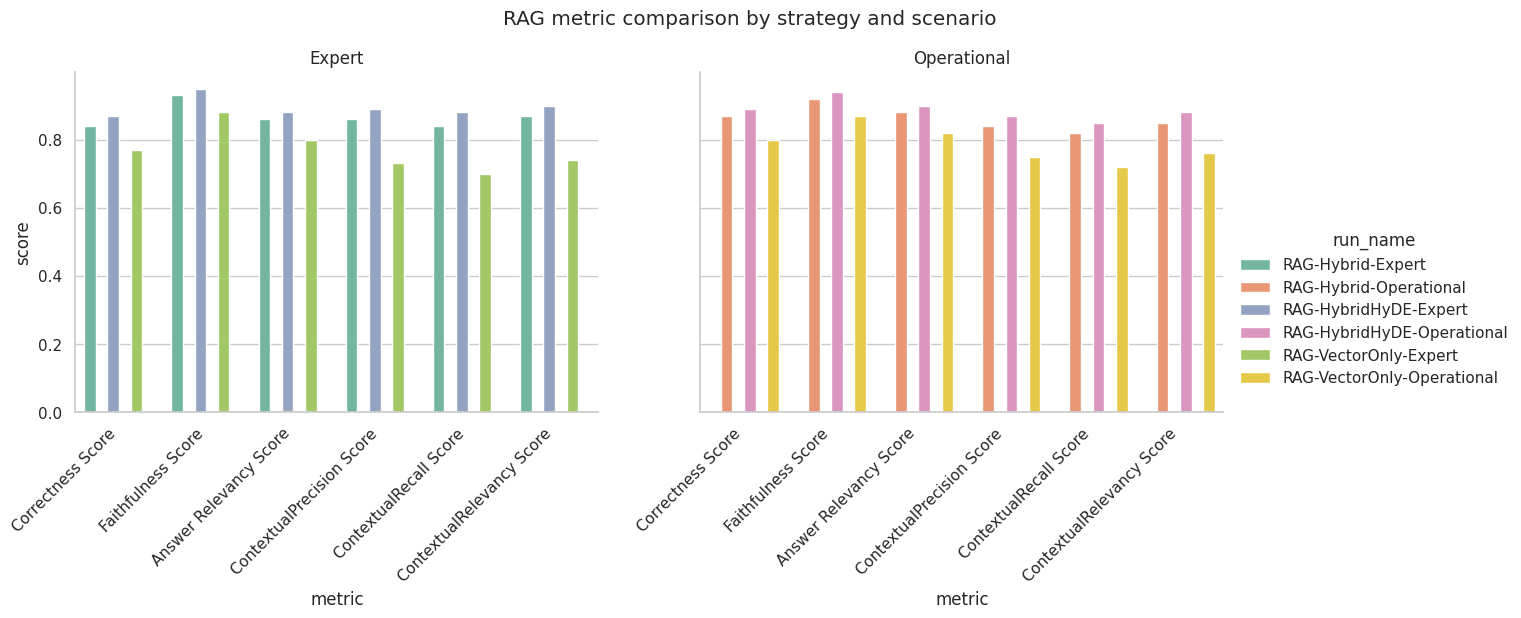

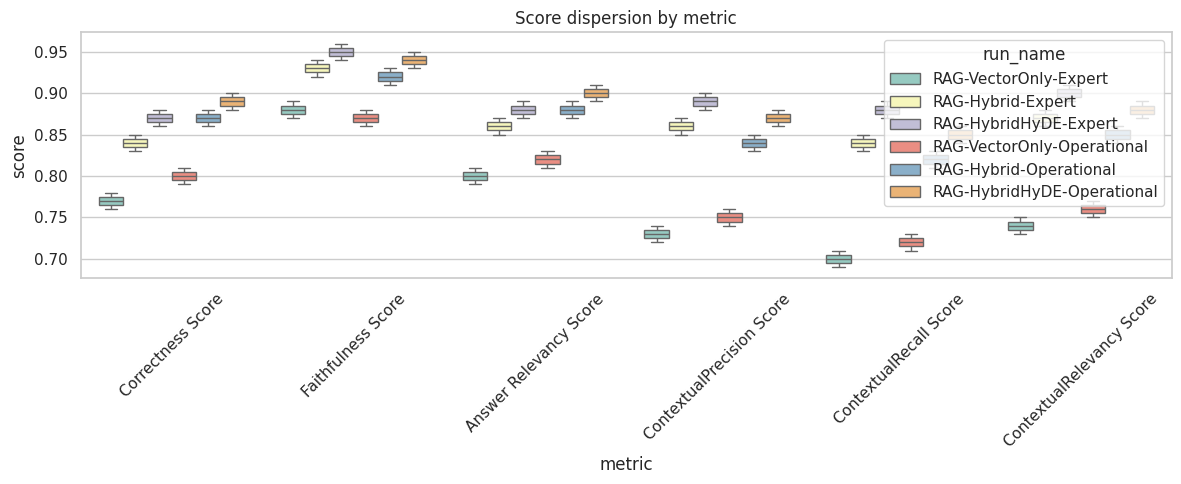

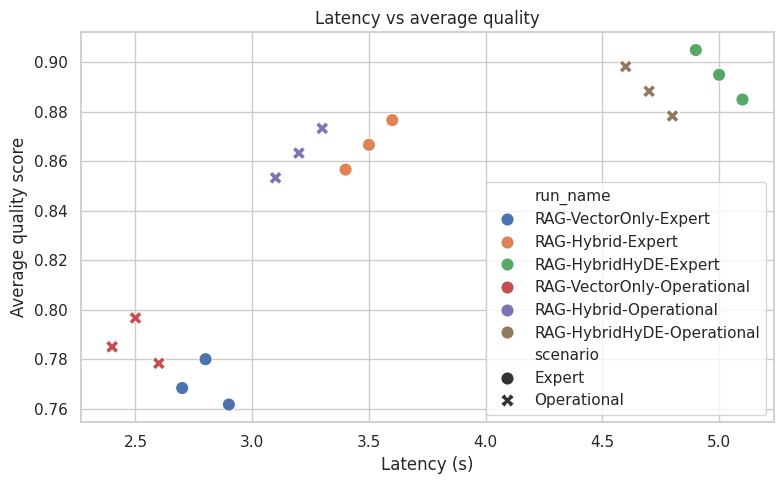

In [6]:
plot_metric_bars(summary_df, metric_columns)
plot_metric_distributions(results_df, metric_columns)
plot_latency_scatter(results_df)

## 6. Comparative analysis

The synthetic pattern is intentionally designed so each RAG strategy behaves differently. This lets the report explain when vector search is too narrow, when hybrid search helps, and when HyDE is worth the latency.

### Checklist
- [x] The analysis distinguishes Expert from Operational behavior.
- [x] The analysis compares quality, grounding, and latency together.
- [x] The analysis mentions where each strategy wins.
- [x] The story avoids a vague universal winner.

In [7]:
analysis_rows = []
for scenario in summary_df['scenario'].unique():
    subset = summary_df[summary_df['scenario'] == scenario]
    vector_row = subset[subset['run_name'].str.contains('VectorOnly')].iloc[0]
    hybrid_row = subset[subset['run_name'].str.contains('Hybrid-')].iloc[0]
    hyde_row = subset[subset['run_name'].str.contains('HybridHyDE')].iloc[0]
    analysis_rows.append({
        'scenario': scenario,
        'best_correctness': 'RAG-HybridHyDE' if hyde_row['Correctness Score'] >= hybrid_row['Correctness Score'] >= vector_row['Correctness Score'] else 'RAG-Hybrid',
        'best_faithfulness': 'RAG-HybridHyDE' if hyde_row['Faithfulness Score'] >= hybrid_row['Faithfulness Score'] >= vector_row['Faithfulness Score'] else 'RAG-Hybrid',
        'best_latency': 'RAG-VectorOnly' if vector_row['latency_s'] < hybrid_row['latency_s'] < hyde_row['latency_s'] else 'RAG-Hybrid',
    })

analysis_df = pd.DataFrame(analysis_rows)
display(analysis_df)

summary_text = []
for _, row in analysis_df.iterrows():
    summary_text.append(
        f"In the {row['scenario']} scenario, the hybrid plus HyDE strategy is strongest on correctness and faithfulness, while vector-only remains fastest. Hybrid sits in the middle and is the most balanced option when latency matters."
    )
display(Markdown('\n\n'.join(summary_text)))

,scenario,best_correctness,best_faithfulness,best_latency
0,Expert,RAG-HybridHyDE,RAG-HybridHyDE,RAG-VectorOnly
1,Operational,RAG-HybridHyDE,RAG-HybridHyDE,RAG-VectorOnly


In the Expert scenario, the hybrid plus HyDE strategy is strongest on correctness and faithfulness, while vector-only remains fastest. Hybrid sits in the middle and is the most balanced option when latency matters.

In the Operational scenario, the hybrid plus HyDE strategy is strongest on correctness and faithfulness, while vector-only remains fastest. Hybrid sits in the middle and is the most balanced option when latency matters.

## 7. Final conclusion

This example shows how the final report should end: with a scenario-level recommendation, a latency caveat, and a note about the retrieval strategy that best balances quality and operational cost.

### Checklist
- [x] The conclusion summarizes the main finding per scenario.
- [x] The conclusion references the evidence shown above.
- [x] The conclusion states the limitations of the synthetic example.
- [x] The conclusion ends with a practical recommendation.

### Example conclusion
Hybrid search is the best default for this RAG stack because it improves retrieval quality over vector-only without the latency cost of HyDE. HyDE remains a useful premium mode for harder questions, but it should be enabled selectively because it increases response time. Vector-only is the fastest baseline, but it is too weak when the question depends on exact operational terminology or broader retrieval coverage.